<a href="https://colab.research.google.com/github/Daniel-EDC/StudentPerformanceModel/blob/main/StudentPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# dataset has 15 columns and 2392 students
df = pd.read_csv("Student_performance_data _.csv")

#Note, this is to delete Gradeclass if GPA is what I am after
df = df.drop(columns=["GradeClass"]) #It is the opposite of GPA

#Other notes: Ethnicity (0=Caucasian, 1=African American, 2=Asian, 3=Other);
#             ParentalEducation (0=None, 1=High School, 2=Some College, 3=Bachelor’s, 4=Higher); ParentalSupport (0=None, 1=Low, 2=Moderate, 3=High, 4=Very High).

# Head of dataset
df.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061


In [2]:
# Shape of dataset
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns:\n", df.columns)

# Data types
print("\nData Types:\n")
print(df.dtypes)

Dataset Shape: (2392, 14)

Columns:
 Index(['StudentID', 'Age', 'Gender', 'Ethnicity', 'ParentalEducation',
       'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport',
       'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA'],
      dtype='object')

Data Types:

StudentID              int64
Age                    int64
Gender                 int64
Ethnicity              int64
ParentalEducation      int64
StudyTimeWeekly      float64
Absences               int64
Tutoring               int64
ParentalSupport        int64
Extracurricular        int64
Sports                 int64
Music                  int64
Volunteering           int64
GPA                  float64
dtype: object


In [3]:
df.describe(include='all') #statistics

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA
count,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000
mean,2196.500000,16.468645,0.510870,0.877508,1.746237,9.771992,14.541388,0.301421,2.122074,0.383361,0.303512,0.196906,0.157191,1.906186
std,690.655244,1.123798,0.499986,1.028476,1.000411,5.652774,8.467417,0.458971,1.122813,0.486307,0.459870,0.397744,0.364057,0.915156
min,1001.000000,15.000000,0.000000,0.000000,0.000000,0.001057,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1598.750000,15.000000,0.000000,0.000000,1.000000,5.043079,7.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.174803
50%,2196.500000,16.000000,1.000000,0.000000,2.000000,9.705363,15.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.893393
75%,2794.250000,17.000000,1.000000,2.000000,2.000000,14.408410,22.000000,1.000000,3.000000,1.000000,1.000000,0.000000,0.000000,2.622216
max,3392.000000,18.000000,1.000000,3.000000,4.000000,19.978094,29.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,4.000000


In [4]:
# Check missing values
missing_values = df.isnull().sum()
print("Missing Values in each Column:\n")
print(missing_values)

#no missing values

Missing Values in each Column:

StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
dtype: int64


In [5]:
print("Number of duplicate rows is:", df.duplicated().sum())# no duplicate rows

Number of duplicate rows is: 0


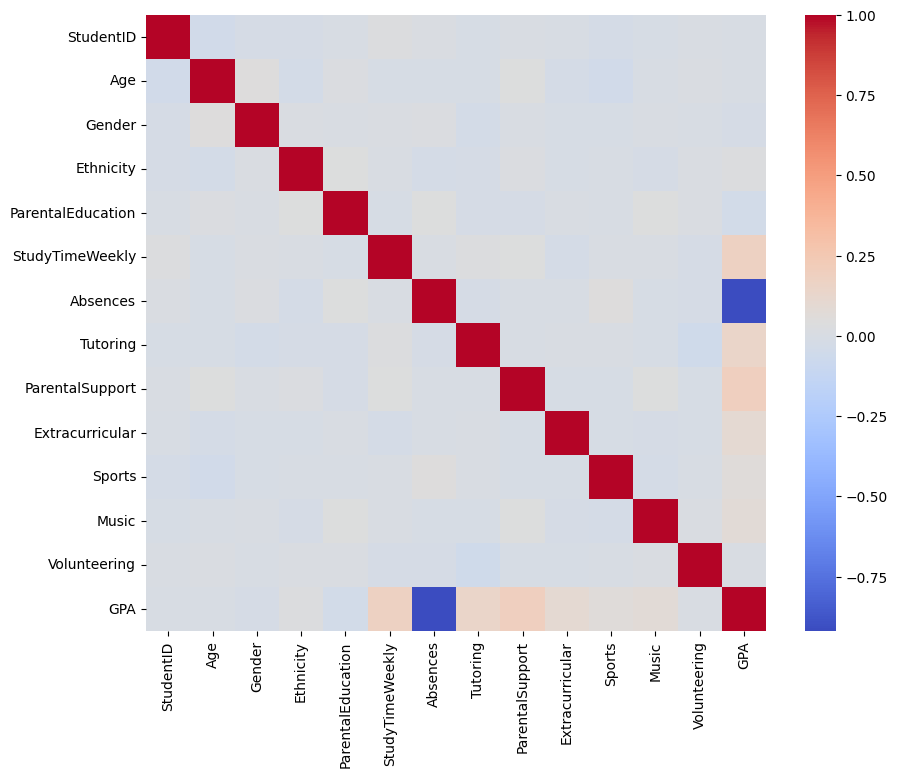

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
# this is a correlation matrix
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=False, cmap="coolwarm")
plt.show()

#this shows that Abscneces is blue beucase its bad(so look for no), and tutoring, studytime, and parental support are redish

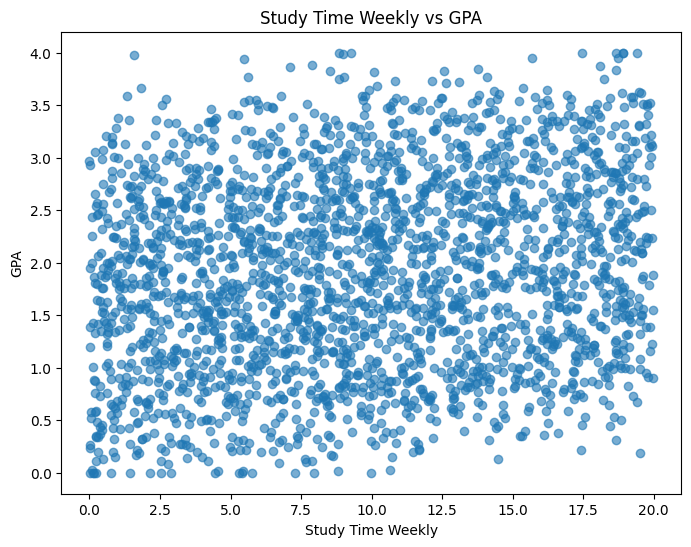

In [7]:
#practice scattergraph:

import matplotlib.pyplot as plt #imot

plt.figure(figsize=(8,6))
plt.scatter(df['StudyTimeWeekly'], df['GPA'], alpha=0.6)
plt.xlabel('Study Time Weekly')
plt.ylabel('GPA')
plt.title('Study Time Weekly vs GPA')
plt.show()

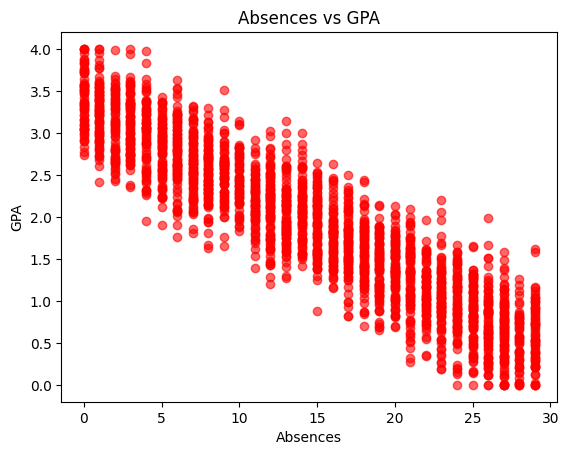

In [8]:
# The best one is absences

plt.scatter(df['Absences'], df['GPA'], alpha=0.6, color='red')
plt.xlabel('Absences')
plt.ylabel('GPA')
plt.title('Absences vs GPA')
plt.show()

#this one is better becuase it shows a pattern and relationship

In [9]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(df[['Absences']], df['GPA'])

print("Many Absences")
reg.predict([[10]]) # the less, the better the GPA

Many Absences


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([2.35741463])

In [10]:
print("Few Absences")
reg.predict([[2]])

Few Absences


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([3.15228762])

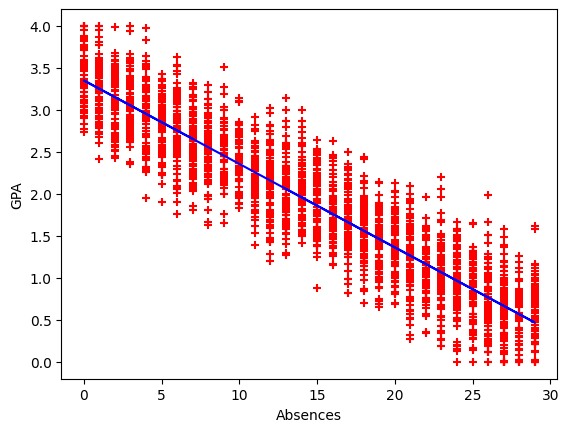

In [11]:
# Scatter plot
plt.xlabel('Absences')
plt.ylabel('GPA')
plt.scatter(df['Absences'], df['GPA'], color='red', marker='+')

# Regression line
plt.plot(df['Absences'], reg.predict(df[['Absences']]), color='blue')
# uses Absences as the input to predict GPA, because GPA is what the model was trained to predict

plt.show()

In [12]:
print("Now for the KNN Area.")

Now for the KNN Area.


In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

# Feature (input) and Target (output)
X = df[['Absences']]
y = df['GPA']

# Split data into training and testing
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

# Create KNN Regressor
knn = KNeighborsRegressor(n_neighbors=5)

# Train the model
knn.fit(x_train, y_train)

# Predict GPA values
y_pred = knn.predict(x_test)


In [61]:
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)


Mean Squared Error: 0.14510067712226232


In [62]:
# Example predictions
print("Many Absences")
print(knn.predict([[10]]))

Many Absences
[2.18980233]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


In [63]:
print("Few Absences")
print(knn.predict([[1]]))

Few Absences
[3.15812993]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


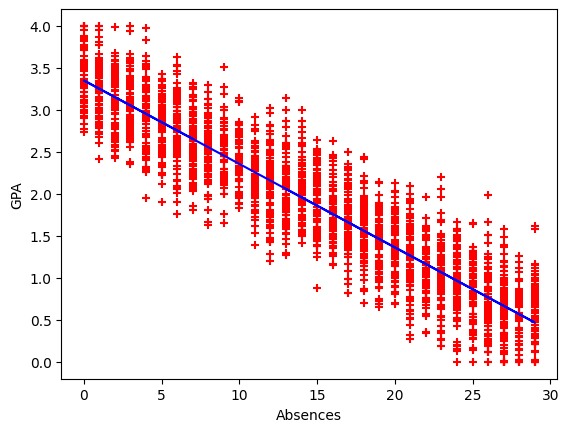

In [70]:
# Scatter plot of data
plt.xlabel('Absences')
plt.ylabel('GPA')
plt.scatter(df['Absences'], df['GPA'], color='red', marker='+')

# Plot predictions
plt.plot(df['Absences'], reg.predict(df[['Absences']]), color='blue')

plt.show()

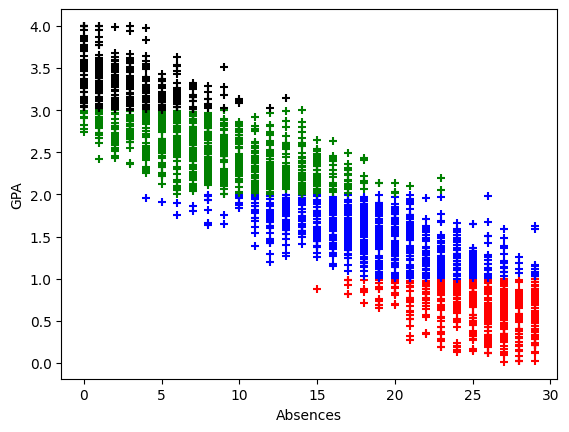

In [65]:
# Create GPA categories (Very Low, Low, Medium, High)
df['target'] = pd.cut(df['GPA'],
                      bins=[0, 1, 2, 3, 4.0],
                      labels=[0, 1, 2, 3])



# Split dataset into groups for plotting
dr0 = df[df.target==0]
dr1 = df[df.target==1]
dr2 = df[df.target==2]
dr3 = df[df.target==3]

# Scatter plot (Absences vs GPA groups)
plt.scatter(dr0['Absences'], dr0['GPA'], color='red', marker='+')
plt.scatter(dr1['Absences'], dr1['GPA'], color='blue', marker='+')
plt.scatter(dr2['Absences'], dr2['GPA'], color='green', marker='+')
plt.scatter(dr3['Absences'], dr3['GPA'], color='black', marker='+')

plt.xlabel("Absences")
plt.ylabel("GPA")
plt.show()

In [66]:
x = df.drop(['target'], axis='columns')
y = df.target

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1)

len(x_train)
len(x_test)

479

In [67]:
from sklearn.preprocessing import StandardScaler

# Create categories
df['target'] = pd.cut(df['GPA'],
                     bins=[-0.01, 1, 2, 3, 4.0],
                     labels=[0, 1, 2, 3])

# Features and labels
x = df[['Absences']]
y = df['target']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1)

# Scale data
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train) #fit
x_test = scaler.transform(x_test)

# Train classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)

# Predict
y_pred = knn.predict(x_test)


In [68]:
# Evaluation
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[ 59  36   0   0]
 [ 13 122  33   0]
 [  0  20 123  21]
 [  0   0  22  30]]


In [69]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.62      0.71        95
           1       0.69      0.73      0.71       168
           2       0.69      0.75      0.72       164
           3       0.59      0.58      0.58        52

    accuracy                           0.70       479
   macro avg       0.70      0.67      0.68       479
weighted avg       0.70      0.70      0.70       479



In [53]:
print("Now for the Unsupervised data test, useing Clustering by K-Means.")

Now for the Unsupervised data test, useing Clustering by K-Means.


In [72]:
# Import required libraries for data handling, visualization, and ML
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

# Machine learning tools
from sklearn.cluster import KMeans                # K-Means clustering (unsupervised learning)
from sklearn import linear_model                 # Linear regression model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

# Load again
df = pd.read_csv('Student_performance_data _.csv')




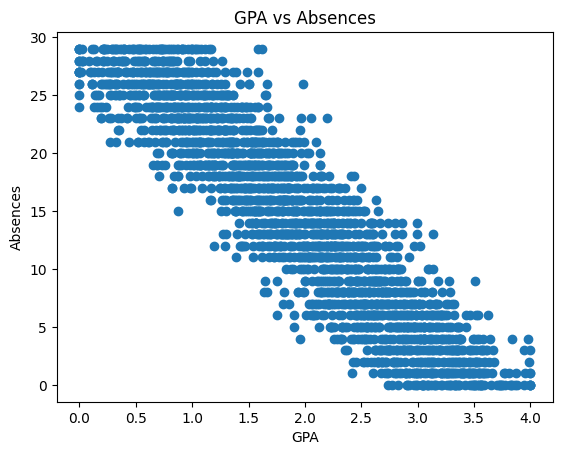

In [73]:
# Scatter plot to visualize relationship between GPA and Absences
plt.scatter(df.GPA, df.Absences)
plt.xlabel("GPA")
plt.ylabel("Absences")
plt.title("GPA vs Absences")
plt.show()

# This helps us see if natural groupings (clusters) exist

In [74]:
# Select feature for clustering = Absences
X = df[['Absences']]

# Target variable = GPA
y = df['GPA']

# scale  data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# why? -- Scaling ensures distance calculations are meaningful

In [76]:
# Create K-Means model with 3 clusters
km = KMeans(n_clusters=3, random_state=42)

# Fit model and assign each data point to a cluster
df['Cluster'] = km.fit_predict(X_scaled)

# Add cluster as an additional feature
X_clustered = df[['Absences', 'Cluster']]

In [77]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_clustered,
    y,
    test_size=0.2,
    random_state=42
)

In [78]:
# Create linear regression model
reg = linear_model.LinearRegression()

# Train model using Absences + Cluster
reg.fit(X_train, y_train)

# Predict GPA on test data
y_pred = reg.predict(X_test)

In [82]:
# Predict GPA for a new student with 5 absences

new_data = pd.DataFrame({'Absences': [5]})

# Scale the new data (same scaler used before)
new_data_scaled = scaler.transform(new_data)

# Predict which cluster this new student belongs to
new_cluster = km.predict(new_data_scaled)

# Combine Absences + Cluster for prediction
new_data_clustered = pd.DataFrame({
    'Absences': [5],
    'Cluster': new_cluster
})

# Predict GPA
new_gpa_pred = reg.predict(new_data_clustered)

print("Predicted GPA:", new_gpa_pred[0])

Predicted GPA: 2.8447461118819373


Score: 0.8482273898573575


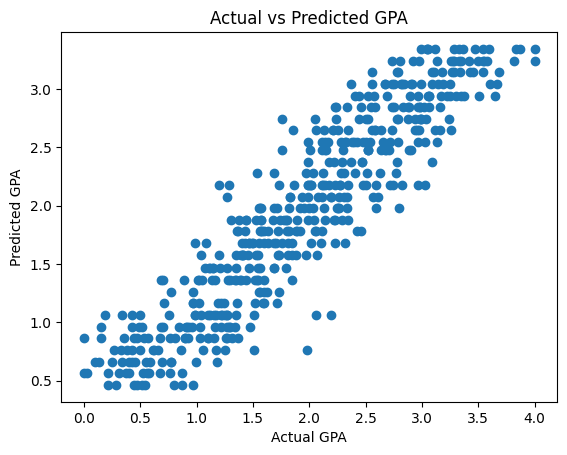

In [83]:
# R^2 score (how well the model explains variance)
score = reg.score(X_test, y_test)
print("Score:", score)

# Plot actual vs predicted GPA
plt.scatter(y_test, y_pred)
plt.xlabel("Actual GPA")
plt.ylabel("Predicted GPA")
plt.title("Actual vs Predicted GPA")
plt.show()

In [88]:
def gpa_label(gpa):
    if gpa < 2.5:
        return 0
    elif gpa < 3.5:
        return 1
    else:
        return 2

df['GPA_Label'] = df['GPA'].apply(gpa_label)

# Compare actual GPA categories with clusters
cm = confusion_matrix(df['GPA_Label'], df['Cluster'])
print("Confusion Matrix:\n", cm)


Confusion Matrix:
 [[678 881 127]
 [115   0 514]
 [  1   0  76]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.40      0.55      1686
           1       0.00      0.00      0.00       629
           2       0.11      0.99      0.19        77

    accuracy                           0.32      2392
   macro avg       0.32      0.46      0.25      2392
weighted avg       0.61      0.32      0.39      2392



In [89]:
# Detailed classification metrics
print("\nClassification Report:")
print(classification_report(df['GPA_Label'], df['Cluster']))


Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.40      0.55      1686
           1       0.00      0.00      0.00       629
           2       0.11      0.99      0.19        77

    accuracy                           0.32      2392
   macro avg       0.32      0.46      0.25      2392
weighted avg       0.61      0.32      0.39      2392



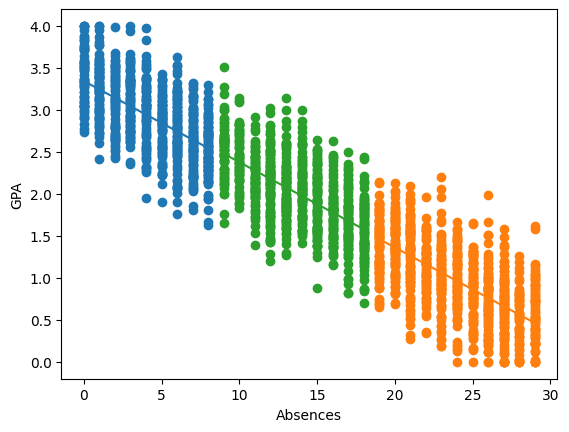

In [91]:
  for cluster in df['Cluster'].unique():
    cluster_data = df[df['Cluster'] == cluster]

    X_cluster = cluster_data[['Absences', 'Cluster']]
    y_cluster = cluster_data['GPA']

    sorted_idx = X_cluster['Absences'].argsort()
    X_sorted = X_cluster.iloc[sorted_idx]
    y_pred_cluster = reg.predict(X_sorted)

    plt.scatter(cluster_data['Absences'], y_cluster, label=f'Cluster {cluster}')
    plt.plot(X_sorted['Absences'], y_pred_cluster)

plt.xlabel("Absences")
plt.ylabel("GPA")
plt.show()